# Full Waveform Inversion (FWI) dengan *Deep Prior*
### Neural Reparametrization untuk Proses Inversi Seismik

**Machine Learning in Geoscience**

Notebook ini membangun sebuah model *deep learning* sederhana untuk melakukan **Full Waveform Inversion (FWI)** menggunakan pendekatan *deep prior* (disebut juga *neural reparametrization*). Kita akan mengimplementasikan semuanya dari nol dengan PyTorch, mulai dari forward modeling persamaan gelombang akustik yang *differentiable*, sampai proses inversi yang dipandu oleh sebuah *neural network*.

Studi kasus yang dipakai adalah **model garam (salt model)** sederhana: sebuah tubuh berkecepatan tinggi (mensimulasikan tubuh garam) yang tertanam di dalam medium berlapis. Tujuan inversi adalah merekonstruksi posisi dan bentuk tubuh garam tersebut hanya dari data gelombang yang terekam di receiver.

**Apa yang akan Anda pelajari:**
1. Konsep dasar FWI sebagai sebuah masalah optimisasi.
2. Bagaimana membangun forward solver persamaan gelombang yang *differentiable* sehingga *autodiff* dapat menghitung gradient (setara dengan metode *adjoint-state*).
3. Ide inti *deep prior*: mengganti grid kecepatan dengan output sebuah CNN, lalu mengoptimasi *weights* jaringan tersebut.
4. Mengapa arsitektur CNN memberikan *implicit regularization* yang membuat hasil inversi lebih bersih dibanding FWI konvensional.


## 1. Latar Belakang: Apa itu FWI?

**Full Waveform Inversion (FWI)** adalah teknik untuk mengestimasi model kecepatan bawah permukaan dengan cara mencocokkan seluruh bentuk gelombang (*full waveform*) hasil simulasi dengan data seismik yang terukur di lapangan, bukan hanya waktu tiba (*traveltime*) seperti pada tomografi konvensional.

Secara konseptual, FWI terdiri dari dua bagian:

**a. Forward problem.** Diberikan sebuah model kecepatan $v(x,z)$, kita mensimulasikan perambatan gelombang dan merekam responnya di receiver. Untuk medium akustik, perambatan diatur oleh persamaan gelombang akustik:

$$\frac{1}{v^2}\frac{\partial^2 u}{\partial t^2} = \nabla^2 u + s(t)$$

dengan $u(x,z,t)$ adalah medan tekanan (*wavefield*), dan $s(t)$ adalah source. Operator yang memetakan model ke data kita tulis sebagai $d_{pred} = F[v]$.

**b. Inverse problem.** Kita mencari model $v$ yang membuat data prediksi $F[v]$ sedekat mungkin dengan data observasi $d_{obs}$. Ini dirumuskan sebagai minimisasi fungsi *misfit* (juga disebut *objective function* atau *loss*):

$$J(v) = \frac{1}{2}\, \lVert F[v] - d_{obs} \rVert^2$$

Model diperbarui secara iteratif mengikuti arah negatif gradient:

$$v \leftarrow v - \alpha\, \nabla_v J$$

dengan $\alpha$ adalah *learning rate* (atau *step length*). Pada FWI klasik, gradient $\nabla_v J$ dihitung dengan metode *adjoint-state*. Dalam notebook ini, karena forward solver kita *differentiable*, gradient dihitung otomatis oleh *automatic differentiation* (autodiff) PyTorch. Keduanya secara matematis ekuivalen.

**Tantangan utama FWI:**
- **Non-linear dan non-convex.** Hubungan antara model dan data sangat tidak linear, sehingga optimisasi mudah terjebak di *local minimum*.
- **Cycle skipping.** Jika model awal terlalu jauh dari model sebenarnya, gelombang prediksi bisa bergeser lebih dari setengah periode terhadap data, dan optimisasi gagal konvergen ke solusi yang benar.
- **Ill-posed.** Banyak model berbeda dapat menghasilkan data yang mirip, terutama di daerah dengan iluminasi rendah. Akibatnya hasil inversi sering penuh artefak.

Tantangan terakhir inilah yang akan kita atasi dengan *deep prior*.


## 2. Ide Inti: Deep Prior (Neural Reparametrization)

Pada FWI konvensional, *unknown* yang dioptimasi adalah nilai kecepatan di setiap titik grid secara langsung. Karena tidak ada batasan struktur, hasilnya bebas menjadi kasar dan penuh artefak (misalnya jejak akuisisi di sekitar source dan receiver).

Ide *deep prior* adalah **mengganti parametrisasi model**. Alih-alih mengoptimasi grid kecepatan secara langsung, kita menyatakan model kecepatan sebagai output sebuah *convolutional neural network* (generator) $G_\theta$ yang menerima input tetap berupa noise $z$:

$$v_\theta = v_{bg} + \Delta v_{max}\cdot \tanh\big(G_\theta(z)\big)$$

Di sini $v_{bg}$ adalah model background halus (model awal), dan suku kedua adalah perturbasi yang dihasilkan jaringan. Yang kita optimasi sekarang adalah *weights* $\theta$ dari jaringan, bukan piksel kecepatan:

$$\min_\theta\; J(\theta) = \frac{1}{2}\,\lVert F[v_\theta] - d_{obs}\rVert^2$$

Gradient $\nabla_\theta J$ mengalir mundur (*backpropagation*) melalui dua tahap sekaligus: melalui forward solver gelombang $F$, lalu melalui generator $G_\theta$. Autodiff PyTorch menangani keduanya secara otomatis.

**Mengapa ini membantu?**

Konsep ini berakar pada *Deep Image Prior* (Ulyanov et al., 2018), yang menunjukkan bahwa struktur arsitektur CNN itu sendiri sudah merupakan sebuah *prior* yang kuat. Jaringan konvolusi secara alami lebih mudah menghasilkan citra yang halus dan koheren secara spasial dibanding noise acak. Ketika dipakai untuk FWI (lihat misalnya Wu and McMechan, 2019; He and Wang, 2021), efeknya adalah *implicit regularization*: hasil inversi cenderung berupa struktur yang masuk akal secara geologi (tubuh yang kompak) dan jejak akuisisi tertekan, **tanpa perlu dataset pelatihan sama sekali**. Inversi tetap bersifat *unsupervised* dan hanya bekerja pada satu kasus data.


## 3. Persiapan: Import dan Konfigurasi

Kita gunakan PyTorch sebagai *engine* utama. Seluruh perhitungan dijalankan di CPU agar mudah direproduksi. Jika tersedia GPU, kode dapat dipercepat dengan mengganti `device`.


In [1]:
import math, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| device:", device)

# ---- Parameter grid dan fisika ----
nz, nx = 48, 56        # jumlah titik grid (kedalaman z, lateral x)
h      = 15.0          # spasi grid (meter)
dt     = 2.0e-3        # langkah waktu (detik)
nt     = 400           # jumlah langkah waktu
f0     = 5.0           # frekuensi puncak Ricker wavelet (Hz)
pml    = 8             # lebar lapisan sponge (absorbing boundary)

# Batas kecepatan fisik. Clamp ini sekaligus menjaga kestabilan numerik (syarat CFL).
VMIN, VMAX = 1700.0, 3400.0

print("Domain:", nz*h, "m (z) x", nx*h, "m (x)")
print("Syarat CFL (harus < 0.707):", round(VMAX*dt/h, 3))


ModuleNotFoundError: No module named 'torch'

## 4. Model Kecepatan: Salt Model dan Model Awal

Kita definisikan dua model:

- **Model sebenarnya (`v_true`)**: background dengan gradient kecepatan yang naik terhadap kedalaman (1900 sampai 2600 m/s), ditambah sebuah tubuh garam elips berkecepatan tinggi (2950 m/s) di tengah domain. Inilah yang ingin kita rekonstruksi.
- **Model awal (`v_bg`)**: hanya background halus tanpa garam. Inilah titik awal inversi. Dalam praktik FWI, model awal yang halus dan masuk akal sangat penting untuk menghindari *cycle skipping*.

Kontras kecepatan sengaja dibuat moderat dan frekuensi source dibuat rendah, agar inversi berada pada rezim yang stabil dan mudah dipahami untuk pembelajaran.


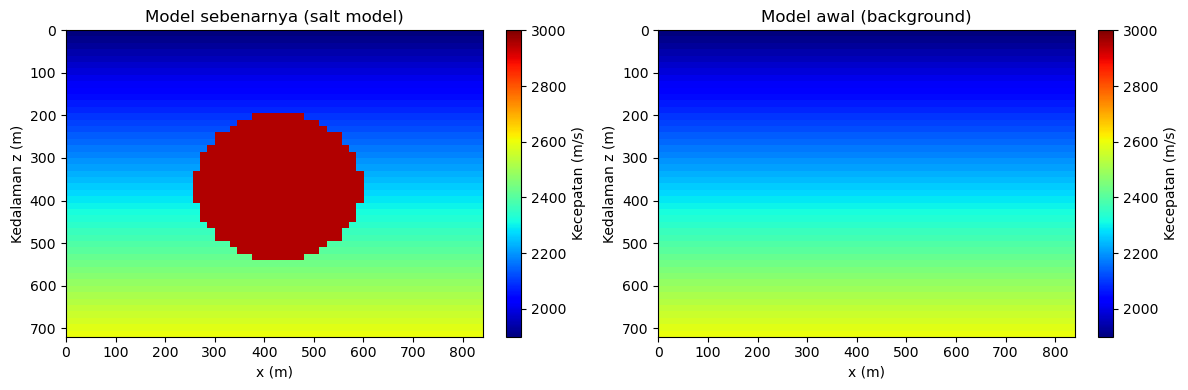

In [ ]:
def background_model():
    v = np.zeros((nz, nx), dtype=np.float32)
    for iz in range(nz):
        v[iz, :] = 1900.0 + (iz / (nz - 1)) * 700.0   # gradient 1900 -> 2600 m/s
    return v

def true_model(salt_velocity=2950.0):
    v = background_model().copy()
    cz, cx = int(nz * 0.5), int(nx * 0.5)     # pusat tubuh garam
    rz, rx = nz * 0.24, nx * 0.20             # radius (dalam jumlah grid)
    zz, xx = np.meshgrid(np.arange(nz), np.arange(nx), indexing="ij")
    ellipse = ((zz - cz) / rz) ** 2 + ((xx - cx) / rx) ** 2 <= 1.0
    v[ellipse] = salt_velocity
    return v

v_true = torch.tensor(true_model(), device=device)
v_bg   = torch.tensor(background_model(), device=device)   # model awal (starting model)

# ---- Visualisasi ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ext = [0, nx*h, nz*h, 0]   # tampilkan dalam meter, kedalaman ke bawah
for a, dat, title in zip(ax, [v_true, v_bg], ["Model sebenarnya (salt model)", "Model awal (background)"]):
    im = a.imshow(dat.cpu().numpy(), cmap="jet", vmin=1900, vmax=3000, extent=ext, aspect="auto")
    a.set_title(title); a.set_xlabel("x (m)"); a.set_ylabel("Kedalaman z (m)")
    plt.colorbar(im, ax=a, fraction=0.046, label="Kecepatan (m/s)")
plt.tight_layout(); plt.show()


## 5. Geometri Akuisisi (Cross-hole / Transmission)

Agar tubuh garam terkurung iluminasi dari beberapa arah dan masalah inversi menjadi *well-posed* (cocok untuk pembelajaran), kita pakai geometri **cross-hole / transmission**:

- **Source** ditempatkan di sisi kiri dan sisi atas domain.
- **Receiver** ditempatkan di sisi kanan dan sisi bawah domain.

Dengan begitu gelombang menembus medium melewati tubuh garam dari berbagai sudut, sehingga anomali kecepatan dapat dipulihkan dengan baik. Geometri refleksi permukaan (source dan receiver hanya di permukaan) lebih realistis untuk eksplorasi garam, tetapi jauh lebih sulit dan biasanya membutuhkan strategi *multiscale*. Hal ini dibahas sebagai pengembangan lanjutan di akhir notebook.

Kita juga memasang **sponge absorbing boundary**: lapisan tipis di tepi domain yang meredam gelombang agar tidak memantul kembali dan mengganggu data. Penting untuk menempatkan source dan receiver tepat di luar lapisan sponge ini agar sinyalnya tidak ikut teredam.


Jumlah source S = 12 | jumlah receiver R = 72


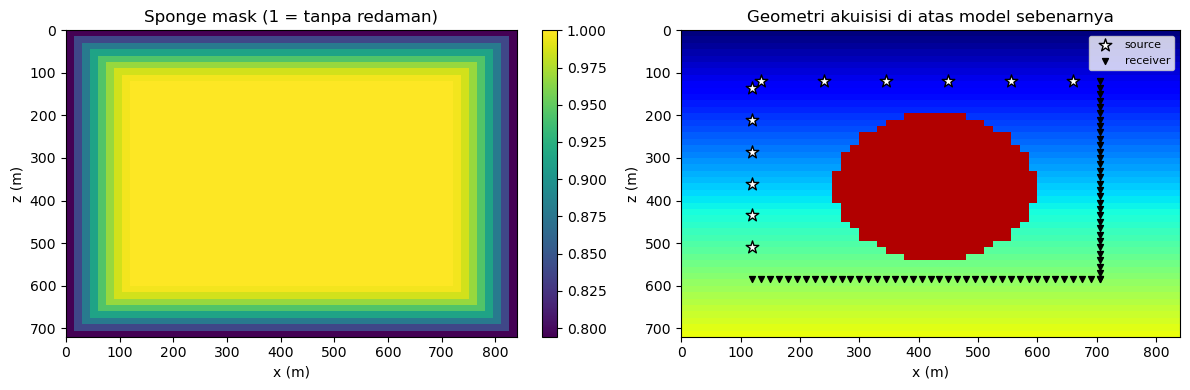

In [ ]:
# ---- Sponge absorbing boundary ----
sponge = torch.ones(nz, nx, device=device)
for i in range(pml):
    val = math.exp(-(0.06 * (pml - i)) ** 2)
    val_t = torch.tensor(val, device=device)
    sponge[i, :]        = torch.minimum(sponge[i, :], val_t)
    sponge[nz-1-i, :]   = torch.minimum(sponge[nz-1-i, :], val_t)
    sponge[:, i]        = torch.minimum(sponge[:, i], val_t)
    sponge[:, nx-1-i]   = torch.minimum(sponge[:, nx-1-i], val_t)

# ---- Source: sisi kiri + sisi atas (di interior, di luar sponge) ----
src_left = [(z, pml) for z in range(pml + 1, nz - pml - 1, 5)]
src_top  = [(pml, x) for x in range(pml + 1, nx - pml - 1, 7)]
src_pos  = src_left + src_top
S = len(src_pos)
sz_list = torch.tensor([a for a, _ in src_pos], device=device)
sx_list = torch.tensor([b for _, b in src_pos], device=device)

# ---- Receiver: sisi kanan + sisi bawah ----
rec_pos = ([(z, nx - 1 - pml) for z in range(pml, nz - pml)] +
           [(nz - 1 - pml, x) for x in range(pml, nx - pml)])
rz_list = torch.tensor([a for a, _ in rec_pos], device=device)
rx_list = torch.tensor([b for _, b in rec_pos], device=device)
R = len(rec_pos)
print("Jumlah source S =", S, "| jumlah receiver R =", R)

# ---- Visualisasi geometri ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
im0 = ax[0].imshow(sponge.cpu().numpy(), cmap="viridis", extent=ext, aspect="auto")
ax[0].set_title("Sponge mask (1 = tanpa redaman)"); ax[0].set_xlabel("x (m)"); ax[0].set_ylabel("z (m)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)

ax[1].imshow(v_true.cpu().numpy(), cmap="jet", vmin=1900, vmax=3000, extent=ext, aspect="auto")
ax[1].scatter(sx_list.cpu()*h, sz_list.cpu()*h, c="white", marker="*", s=90, edgecolor="k", label="source")
ax[1].scatter(rx_list.cpu()*h, rz_list.cpu()*h, c="black", marker="v", s=18, label="receiver")
ax[1].set_title("Geometri akuisisi di atas model sebenarnya")
ax[1].set_xlabel("x (m)"); ax[1].set_ylabel("z (m)"); ax[1].legend(loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()


## 6. Source Wavelet (Ricker)

Source seismik dimodelkan sebagai **Ricker wavelet** dengan frekuensi puncak $f_0$. Ricker wavelet adalah turunan kedua negatif dari fungsi Gaussian, dan sangat umum dipakai pada pemodelan seismik karena spektrumnya terkonsentrasi di sekitar $f_0$.

$$s(t) = \big(1 - 2\pi^2 f_0^2 t^2\big)\, e^{-\pi^2 f_0^2 t^2}$$

Frekuensi rendah ($f_0 = 5$ Hz) dipilih agar panjang gelombang cukup besar dibanding spasi grid (menghindari *numerical dispersion*) dan untuk meredam risiko *cycle skipping*.


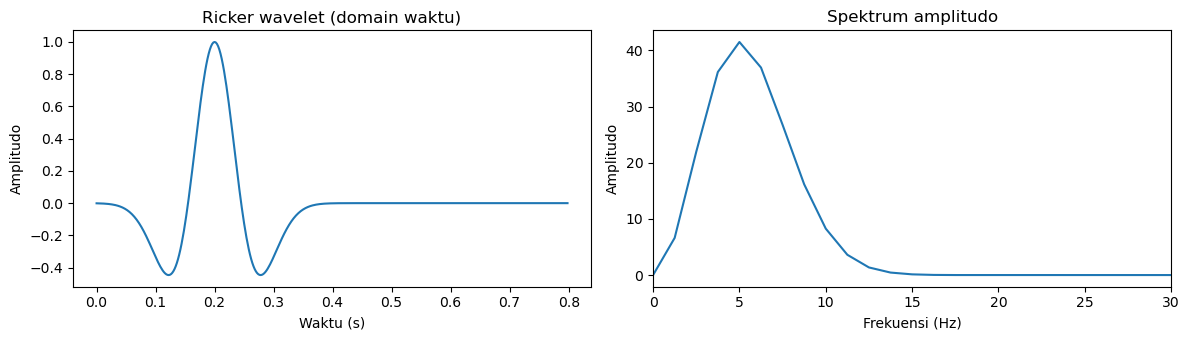

In [ ]:
t_axis = np.arange(nt) * dt - 1.0 / f0       # geser agar puncak ada di awal
ricker = (1 - 2 * (math.pi * f0 * t_axis) ** 2) * np.exp(-(math.pi * f0 * t_axis) ** 2)
src = torch.tensor(ricker.astype(np.float32), device=device)

# Spektrum amplitudo
freq = np.fft.rfftfreq(nt, dt)
amp  = np.abs(np.fft.rfft(ricker))

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].plot(np.arange(nt) * dt, ricker); ax[0].set_title("Ricker wavelet (domain waktu)")
ax[0].set_xlabel("Waktu (s)"); ax[0].set_ylabel("Amplitudo")
ax[1].plot(freq, amp); ax[1].set_xlim(0, 30); ax[1].set_title("Spektrum amplitudo")
ax[1].set_xlabel("Frekuensi (Hz)"); ax[1].set_ylabel("Amplitudo")
plt.tight_layout(); plt.show()


## 7. Forward Solver Gelombang Akustik yang *Differentiable*

Kita selesaikan persamaan gelombang akustik dengan **finite difference**:
- Turunan waktu kedua: skema *central difference* orde dua.
- Operator Laplacian spasial: *stencil* 5 titik, diimplementasikan sebagai konvolusi 2D dengan kernel tetap.

Skema penyelesaiannya (eksplisit, *leap-frog*):

$$u^{n+1} = 2u^{n} - u^{n-1} + (\Delta t)^2 v^2 \big(\nabla^2 u^{n} + f^{n}\big)$$

Beberapa catatan implementasi penting:
- **Vektorisasi atas semua source.** Semua source dihitung sekaligus sebagai dimensi *batch*, sehingga satu pemanggilan fungsi mensimulasikan seluruh *shot*.
- **Differentiable.** Karena seluruh operasi (konvolusi, perkalian, penjumlahan) didukung autodiff, gradient $J$ terhadap parameter model dihitung otomatis oleh PyTorch. Ini ekuivalen dengan gradient *adjoint-state* pada FWI klasik.
- **Injeksi source** memakai faktor fisik $(\Delta t)^2 v^2$ pada lokasi source, dan dilakukan secara non in-place agar aman untuk autodiff.
- **Kestabilan (CFL).** Skema eksplisit ini stabil bila $v\,\Delta t / h < 1/\sqrt{2}$ untuk 2D. Clamp kecepatan ke `VMAX` menjamin syarat ini selalu terpenuhi.

Parameter `return_wavefield` hanya dipakai untuk visualisasi snapshot, dan tidak diaktifkan selama inversi.


In [ ]:
lap_kernel = torch.tensor([[0, 1, 0], [1, -4, 1], [0, 1, 0]],
                          dtype=torch.float32, device=device).view(1, 1, 3, 3) / (h * h)

def forward(v, return_wavefield=False, snap_every=40):
    # Simulasi gelombang akustik untuk semua source sekaligus (batch atas source).
    # Input : v -> tensor kecepatan (nz, nx)
    # Output: data terekam (S, nt, R). Opsional: list snapshot wavefield.
    vsq  = (v * v).view(1, 1, nz, nx)
    coef = dt * dt
    u_prev = torch.zeros(S, 1, nz, nx, device=device)
    u_cur  = torch.zeros(S, 1, nz, nx, device=device)
    v_src  = vsq[0, 0, sz_list, sx_list]      # v^2 di lokasi tiap source
    rec, snaps = [], []
    idx = torch.arange(S, device=device)
    for n in range(nt):
        lap = F.conv2d(u_cur, lap_kernel, padding=1)
        u_next = 2 * u_cur - u_prev + coef * vsq * lap
        # injeksi source (non in-place)
        sfield = torch.zeros(S, 1, nz, nx, device=device)
        sfield[idx, 0, sz_list, sx_list] = coef * v_src * src[n]
        u_next = (u_next + sfield) * sponge
        u_prev = u_cur * sponge
        u_cur  = u_next
        rec.append(u_cur[:, 0, rz_list, rx_list])     # (S, R)
        if return_wavefield and (n % snap_every == 0):
            snaps.append(u_cur[0, 0].detach().cpu().numpy().copy())
    data = torch.stack(rec, dim=1)                     # (S, nt, R)
    if return_wavefield:
        return data, snaps
    return data


## 8. Membangkitkan Data Observasi

Pada studi sintetik seperti ini, data observasi dibuat dengan menjalankan forward solver pada model sebenarnya. Inilah data yang seolah-olah terukur di lapangan, dan akan menjadi target pencocokan saat inversi.

Kita juga menampilkan beberapa **shot gather** (rekaman semua receiver untuk satu source) dan beberapa **snapshot wavefield** agar terlihat bagaimana gelombang merambat dan berinteraksi dengan tubuh garam.


Bentuk data observasi (S, nt, R): (12, 400, 72)


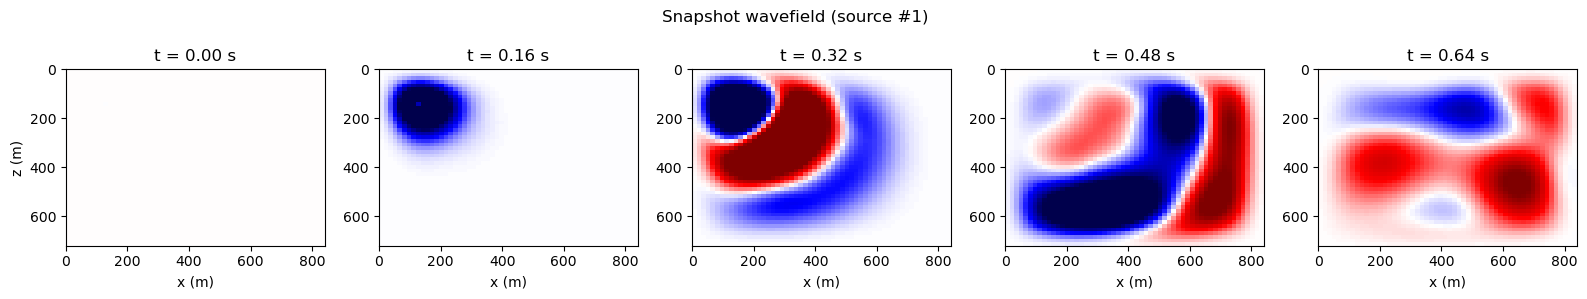

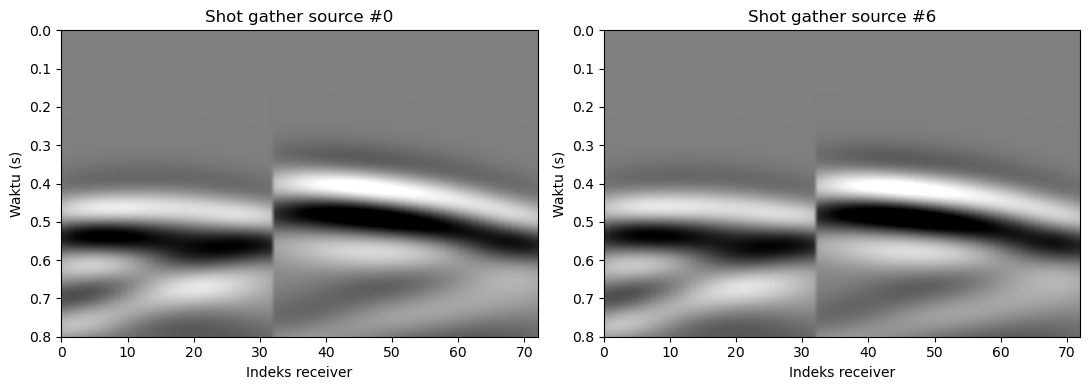

In [ ]:
with torch.no_grad():
    d_obs, snaps = forward(v_true, return_wavefield=True, snap_every=80)
d_obs = d_obs.detach()
print("Bentuk data observasi (S, nt, R):", tuple(d_obs.shape))

# ---- Snapshot perambatan gelombang (source pertama) ----
n_sn = len(snaps)
fig, ax = plt.subplots(1, n_sn, figsize=(3.2 * n_sn, 3))
vmax = np.percentile(np.abs(snaps[-1]), 99) + 1e-6
for k, s in enumerate(snaps):
    ax[k].imshow(s, cmap="seismic", vmin=-vmax, vmax=vmax, extent=ext, aspect="auto")
    ax[k].set_title("t = {:.2f} s".format(k * 80 * dt)); ax[k].set_xlabel("x (m)")
    if k == 0: ax[k].set_ylabel("z (m)")
plt.suptitle("Snapshot wavefield (source #1)"); plt.tight_layout(); plt.show()

# ---- Shot gather untuk dua source ----
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, si in zip(ax, [0, S // 2]):
    g = d_obs[si].cpu().numpy()
    clip = np.percentile(np.abs(g), 98) + 1e-9
    a.imshow(g, cmap="gray", vmin=-clip, vmax=clip, aspect="auto",
             extent=[0, R, nt * dt, 0])
    a.set_title("Shot gather source #{}".format(si)); a.set_xlabel("Indeks receiver"); a.set_ylabel("Waktu (s)")
plt.tight_layout(); plt.show()


## 9. Generator Network (Deep Prior)

Inilah komponen *deep learning*-nya. Generator $G_\theta$ berbentuk *encoder-decoder* konvolusi kecil:
- Menerima input tetap berupa noise $z$ (tidak diubah selama optimisasi).
- *Encoder* menurunkan resolusi sekali (`stride 2`), lalu *decoder* menaikkannya kembali (`Upsample`). Struktur multi-skala inilah yang memberi *implicit regularization* berupa kemulusan spasial.
- Memakai `GroupNorm` dan `LeakyReLU` agar pelatihan stabil.
- Layer output diinisialisasi nol, sehingga di awal perturbasi $\Delta v \approx 0$ dan model dimulai tepat dari background. Ini meniru prinsip FWI: mulai dari model awal yang halus.

Model kecepatan dibentuk sebagai:

$$v_\theta = \mathrm{clamp}\Big(v_{bg} + \Delta v_{max}\cdot \tanh(G_\theta(z)),\; v_{min},\, v_{max}\Big)$$

Fungsi `tanh` membatasi besar perturbasi, dan `clamp` menjamin kecepatan tetap fisik sekaligus stabil secara numerik.


In [ ]:
class Generator(nn.Module):
    def __init__(self, c_in=8, ch=24):
        super().__init__()
        self.enc1 = nn.Sequential(nn.Conv2d(c_in, ch, 3, 1, 1), nn.GroupNorm(6, ch), nn.LeakyReLU(0.2))
        self.enc2 = nn.Sequential(nn.Conv2d(ch, ch*2, 3, 2, 1), nn.GroupNorm(6, ch*2), nn.LeakyReLU(0.2))
        self.mid  = nn.Sequential(nn.Conv2d(ch*2, ch*2, 3, 1, 1), nn.GroupNorm(6, ch*2), nn.LeakyReLU(0.2))
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.dec1 = nn.Sequential(nn.Conv2d(ch*2, ch, 3, 1, 1), nn.GroupNorm(6, ch), nn.LeakyReLU(0.2))
        self.out  = nn.Conv2d(ch, 1, 3, 1, 1)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)   # mulai dari background

    def forward(self, z):
        e1 = self.enc1(z); e2 = self.enc2(e1); m = self.mid(e2)
        d  = self.up(m)[..., :nz, :nx]
        d  = self.dec1(d)
        return self.out(d)

MAX_DV = 1200.0   # perturbasi kecepatan maksimum (m/s)
z_input = torch.randn(1, 8, nz, nx, device=device) * 0.1   # input noise tetap

def make_velocity(net):
    dv = MAX_DV * torch.tanh(net(z_input)).view(nz, nx)
    return torch.clamp(v_bg + dv, VMIN, VMAX)

net = Generator().to(device)
n_param = sum(p.numel() for p in net.parameters())
print("Jumlah parameter (weights) generator:", n_param)


Jumlah parameter (weights) generator: 43849


## 10. Proses Inversi: Optimasi Weights Jaringan

Sekarang kita jalankan inversi. Pada setiap iterasi:
1. Generator menghasilkan model kecepatan $v_\theta$ dari noise tetap.
2. Forward solver mensimulasikan data prediksi $F[v_\theta]$.
3. Kita hitung *loss* berupa *relative data misfit*.
4. *Backpropagation* menghitung gradient loss terhadap *weights* jaringan, melalui forward solver dan generator.
5. Optimizer **Adam** memperbarui weights. *Gradient clipping* dipakai untuk menjaga kestabilan.

Yang dioptimasi adalah weights jaringan, bukan grid kecepatan secara langsung. Kita pantau penurunan *data misfit* sekaligus *model RMSE* (selisih terhadap model sebenarnya) sebagai indikator kualitas rekonstruksi.


In [ ]:
N_ITER = 120
optimizer = torch.optim.Adam(net.parameters(), lr=4e-3)
denom = d_obs.pow(2).sum()

hist_loss, hist_rmse = [], []
t0 = time.time()
for it in range(N_ITER):
    optimizer.zero_grad()
    v_pred = make_velocity(net)
    d_pred = forward(v_pred)
    loss = (d_pred - d_obs).pow(2).sum() / denom          # relative data misfit
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), 2.0)
    optimizer.step()

    with torch.no_grad():
        rmse = (v_pred - v_true).pow(2).mean().sqrt().item()
    hist_loss.append(loss.item()); hist_rmse.append(rmse)
    if it % 20 == 0 or it == N_ITER - 1:
        print("iter {:3d} | data misfit {:.4f} | model RMSE {:6.1f} m/s".format(it, loss.item(), rmse))
print("Selesai dalam {:.1f} detik".format(time.time() - t0))

v_deepprior = make_velocity(net).detach()


iter   0 | data misfit 0.3924 | model RMSE  272.2 m/s
iter  20 | data misfit 0.0606 | model RMSE  208.0 m/s
iter  40 | data misfit 0.0164 | model RMSE  138.1 m/s
iter  60 | data misfit 0.0011 | model RMSE  132.7 m/s
iter  80 | data misfit 0.0003 | model RMSE  115.9 m/s
iter 100 | data misfit 0.0001 | model RMSE  107.1 m/s
iter 119 | data misfit 0.0001 | model RMSE  104.0 m/s
Selesai dalam 75.5 detik


## 11. Hasil Inversi Deep Prior

Kita bandingkan model hasil inversi dengan model sebenarnya dan model awal, lalu lihat kurva penurunan *data misfit* dan *model RMSE*.

Perhatikan bahwa tubuh garam berhasil direkonstruksi pada posisi dan bentuk yang benar, padahal inversi dimulai dari background tanpa garam sama sekali. Kemulusan hasil berasal dari *implicit regularization* arsitektur CNN.


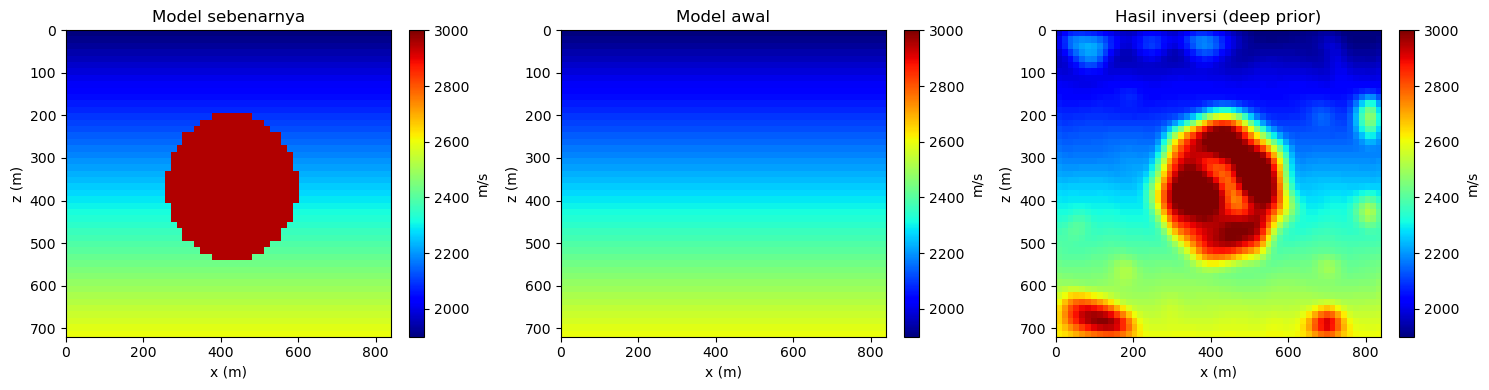

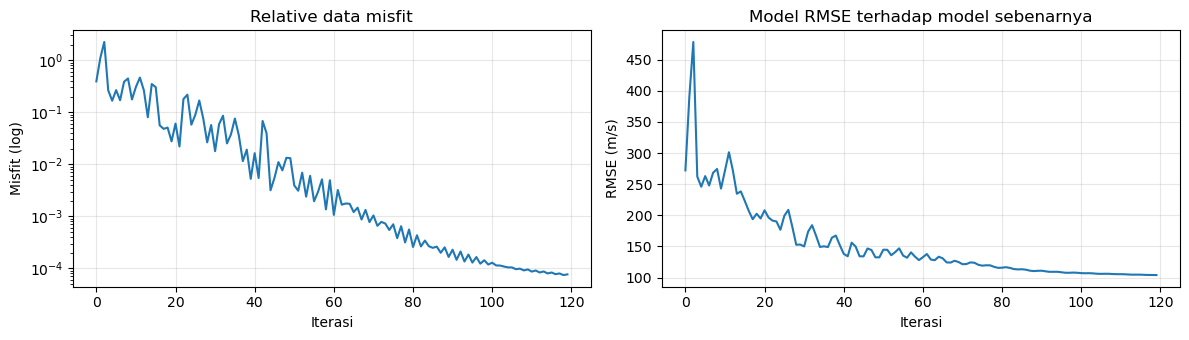

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
panels = [(v_true, "Model sebenarnya"), (v_bg, "Model awal"), (v_deepprior, "Hasil inversi (deep prior)")]
for a, (dat, title) in zip(ax, panels):
    im = a.imshow(dat.cpu().numpy(), cmap="jet", vmin=1900, vmax=3000, extent=ext, aspect="auto")
    a.set_title(title); a.set_xlabel("x (m)"); a.set_ylabel("z (m)")
    plt.colorbar(im, ax=a, fraction=0.046, label="m/s")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].semilogy(hist_loss); ax[0].set_title("Relative data misfit"); ax[0].set_xlabel("Iterasi"); ax[0].set_ylabel("Misfit (log)")
ax[1].plot(hist_rmse); ax[1].set_title("Model RMSE terhadap model sebenarnya"); ax[1].set_xlabel("Iterasi"); ax[1].set_ylabel("RMSE (m/s)")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 12. Perbandingan: FWI Konvensional (Tanpa Deep Learning)

Untuk melihat manfaat *deep prior*, kita jalankan FWI konvensional sebagai pembanding. Di sini *unknown* yang dioptimasi adalah grid kecepatan secara langsung, tanpa jaringan apa pun. Semua hal lain (data, geometri, jumlah iterasi) dibuat sama agar adil.

Kita harapkan hasilnya lebih kasar dan dipenuhi artefak, terutama **jejak akuisisi** di sekitar tepi domain (lokasi source dan receiver), karena tidak ada batasan struktur yang menahan model agar tetap koheren.


In [ ]:
v_direct = v_bg.clone().requires_grad_(True)
opt_d = torch.optim.Adam([v_direct], lr=6.0)
hist_loss_d = []
t0 = time.time()
for it in range(N_ITER):
    opt_d.zero_grad()
    loss = (forward(v_direct.clamp(VMIN, VMAX)) - d_obs).pow(2).sum() / denom
    loss.backward(); opt_d.step()
    with torch.no_grad():
        v_direct.clamp_(VMIN, VMAX)
    hist_loss_d.append(loss.item())
    if it % 20 == 0 or it == N_ITER - 1:
        rmse = (v_direct - v_true).pow(2).mean().sqrt().item()
        print("iter {:3d} | data misfit {:.4f} | model RMSE {:6.1f} m/s".format(it, loss.item(), rmse))
print("Selesai dalam {:.1f} detik".format(time.time() - t0))
v_direct = v_direct.detach()


iter   0 | data misfit 0.3924 | model RMSE  269.9 m/s
iter  20 | data misfit 0.1466 | model RMSE  242.3 m/s
iter  40 | data misfit 0.0918 | model RMSE  222.2 m/s
iter  60 | data misfit 0.0619 | model RMSE  202.7 m/s
iter  80 | data misfit 0.0422 | model RMSE  185.5 m/s
iter 100 | data misfit 0.0286 | model RMSE  170.9 m/s
iter 119 | data misfit 0.0197 | model RMSE  160.4 m/s
Selesai dalam 69.6 detik


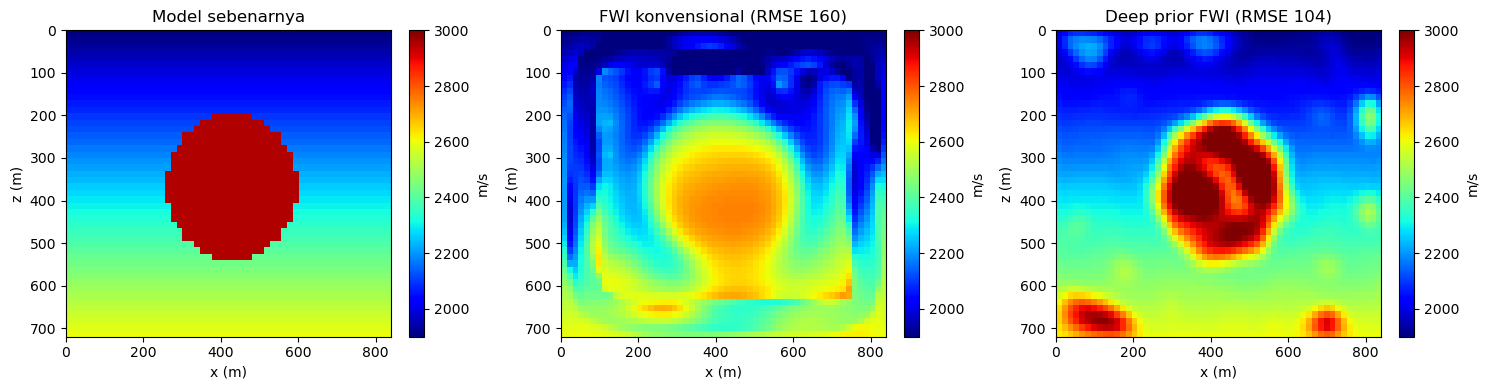

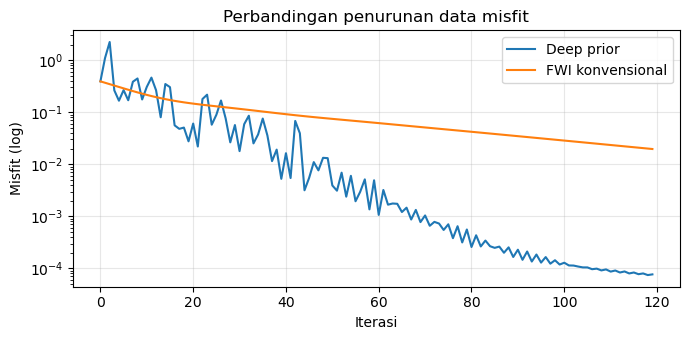

Model RMSE -> deep prior: 103.7 m/s | FWI konvensional: 160.4 m/s


In [ ]:
rmse_dp  = (v_deepprior - v_true).pow(2).mean().sqrt().item()
rmse_dir = (v_direct - v_true).pow(2).mean().sqrt().item()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
panels = [(v_true, "Model sebenarnya"),
          (v_direct, "FWI konvensional (RMSE {:.0f})".format(rmse_dir)),
          (v_deepprior, "Deep prior FWI (RMSE {:.0f})".format(rmse_dp))]
for a, (dat, title) in zip(ax, panels):
    im = a.imshow(dat.cpu().numpy(), cmap="jet", vmin=1900, vmax=3000, extent=ext, aspect="auto")
    a.set_title(title); a.set_xlabel("x (m)"); a.set_ylabel("z (m)")
    plt.colorbar(im, ax=a, fraction=0.046, label="m/s")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7, 3.5))
plt.semilogy(hist_loss, label="Deep prior")
plt.semilogy(hist_loss_d, label="FWI konvensional")
plt.title("Perbandingan penurunan data misfit"); plt.xlabel("Iterasi"); plt.ylabel("Misfit (log)")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

print("Model RMSE -> deep prior: {:.1f} m/s | FWI konvensional: {:.1f} m/s".format(rmse_dp, rmse_dir))


## 13. Diskusi dan Pengembangan Lanjutan

**Apa yang kita amati.** Dengan jumlah iterasi yang sama, *deep prior* menghasilkan rekonstruksi tubuh garam yang lebih kompak dan lebih bersih, dengan jejak akuisisi yang jauh lebih tertekan dibanding FWI konvensional. Model RMSE-nya pun lebih kecil. Ini adalah ilustrasi langsung dari *implicit regularization*: arsitektur CNN membiasakan solusi ke arah citra yang koheren secara spasial, tanpa kita perlu menambahkan suku regularisasi eksplisit dan tanpa dataset pelatihan.

**Keterbatasan eksperimen ini.**
- Geometri *cross-hole* membuat masalah lebih *well-posed* dari pada akuisisi refleksi permukaan yang dipakai pada eksplorasi garam sebenarnya.
- Kontras kecepatan dibuat moderat dan frekuensi rendah untuk menghindari *cycle skipping*.
- Forward solver bersifat akustik 2D dengan absorbing boundary sederhana (sponge), bukan PML penuh.

**Arah pengembangan yang bisa dieksplorasi:**
1. **Akuisisi refleksi permukaan + multiscale.** Lakukan inversi bertahap dari frekuensi rendah ke tinggi untuk mengatasi *cycle skipping* pada geometri permukaan yang realistis.
2. **Regularisasi eksplisit tambahan**, misalnya *total variation*, dikombinasikan dengan deep prior.
3. **Estimasi source** secara simultan bila wavelet tidak diketahui.
4. **Arsitektur generator lain** (U-Net dengan skip connection, atau parametrisasi berbasis koordinat seperti SIREN) untuk mengontrol karakter prior.
5. **Perluasan ke elastic atau 3D**, serta penggunaan GPU untuk grid yang lebih besar.

**Referensi bacaan:**
- Ulyanov, D., Vedaldi, A., Lempitsky, V. (2018). *Deep Image Prior*. CVPR.
- Wu, Y., McMechan, G. A. (2019). *Parametric convolutional neural network-domain full-waveform inversion*. Geophysics.
- He, Q., Wang, Y. (2021). *Reparameterized full-waveform inversion using deep neural networks*. Geophysics.
- Virieux, J., Operto, S. (2009). *An overview of full-waveform inversion in exploration geophysics*. Geophysics.
